#### I : Učitavanje biblioteka i definisanje putanja

<small>

Kao i u prethodnom notebooku, učitavaju se putanje i nazivi slika iz trening i validacionog skupa, koji će se koristiti u procesu pripreme podataka.

</small>

In [61]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

train_path = "./data/DIV2K_train_HR"
val_path = "./data/DIV2K_valid_HR"

train_images = os.listdir(train_path)
val_images = os.listdir(val_path)

FileNotFoundError: [WinError 3] The system cannot find the path specified: './data/DIV2K_valid_HR'

#### II: Testiranje postupka izdvajanja LR–HR patch-eva i downsampling-a

<small>

U ovom koraku proveravamo da li postupak izdvajanja patch-eva funkcioniše ispravno pre nego što ga primenimo na ceo skup podataka.

Prethodno je potrebno definisati **faktor skaliranja** koji ćemo koristiti u **procesu super-rezolucije**.

- Odabrali smo **×4 super-rezoluciju** jer predstavlja **standardan** i **dovoljno izazovan scenario** za **super-rezoluciju**, pri čemu model treba da rekonstruiše sliku čija su širina i visina **četiri puta veće** od **ulazne LR slike**. 
- Ovaj faktor omogućava da se jasno ispita **sposobnost modela** da iz **slike niže rezolucije** obnovi **izgubljene detalje** i dobije **kvalitetniju HR sliku**.

</small>

##### 2.1) Definisanje parametara i formiranje HR patch-a

<small>

Kako originalne slike imaju **različite dimenzije**, za potrebe treniranja biće izdvojeni **delovi slika** **jednakih dimenzija**.

- U ovom projektu koristiće se **HR patch** dimenzija $128×128$ piksela, dok će odgovarajuća **LR verzija** biti dimenzija $32×32$ piksela, što odgovara faktoru **super-rezolucije ×4**.
- **Patch**-evi su **mali delovi** **isečeni** iz **velikih slika** koje **CNN** koristi umesto da obrađuje **celu sliku** odjednom.
- Time **smanjujemo** potrebnu **memoriju**, dobijamo **mnogo više trening primera** iz jedne slike i omogućavamo mreži da **bolje uči lokalne detalje** poput **ivica**, **tekstura** i **finih struktura**.

</small>

In [51]:
# Definisanje parametara

SCALE = 4
HR_SIZE = 128
LR_SIZE = HR_SIZE // SCALE

# HR patch

def random_crop(image, size):
    width, height = image.size

    if width < size or height < size:
        raise ValueError("Slika je manja od zadate dimenzije.")

    left = random.randint(0, width - size)
    top = random.randint(0, height - size)

    crop = image.crop((left, top, left + size, top + size))

    return crop

img = Image.open(os.path.join(train_path, train_images[0])).convert("RGB")

hr_patch = random_crop(img, HR_SIZE)

print("Originalna slika:", img.size)
print("HR patch:", hr_patch.size)

Originalna slika: (2040, 1404)
HR patch: (128, 128)


<small>

> Iz svake visokorezolucione slike **nasumično** se **izdvaja patch** dimenzija $128×128$ piksela.<br>
> Na ovaj način se **velike slike** pretvaraju u **manje uzorke** pogodne za **efikasnije** treniranje neuronske mreže.<br>

> Dimenziju $128×128$ smo **odabrali** kao deo pripreme podataka, jer predstavlja dobar kompromis između **očuvanja dovoljno detalja** za učenje modela, **razumnih memorijskih zahteva** i mogućnosti da se iz velikih **DIV2K** slika dobije **veliki broj trening primera**.<br>

> Po potrebi možemo eksperimentisati i sa **drugim dimenzijama patch**-eva, kao što su $64×64$ ili $256×256$. 

</small>

##### 2.2) Downsampling – formiranje LR slike

<small>

Sada od **HR patch**-a pravimo njegovu **LR verziju**.

- Pošto smo odabrali **×4 super-rezoluciju**, **LR slika** treba da bude **četiri puta manja** po **širini** i **visini** u odnosu na **HR sliku**. 
- Zbog toga se **HR patch** dimenzije $128×128$ smanjuje na $32×32$ piksela: $128 / 4 = 32$
- Na taj način dobijamo $16$ **puta manje piksela**, jer se **obe dimenzije smanjuju četiri puta**. 
- Smanjivanje se vrši pomoću **BICUBIC interpolacije**, čime dobijamo odgovarajući **LR–HR par** koji će se koristiti za treniranje modela super-rezolucije.

</small>

HR patch: (128, 128)
LR patch: (32, 32)


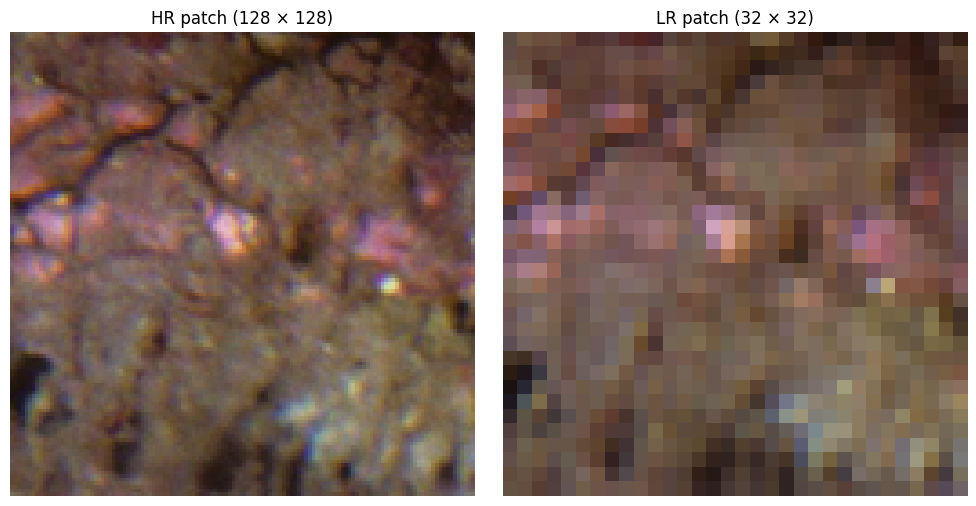

In [59]:
lr_patch = hr_patch.resize((LR_SIZE, LR_SIZE),Image.Resampling.BICUBIC)

print("HR patch:", hr_patch.size)
print("LR patch:", lr_patch.size)

# Prikaz HR i LR patch-a
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(hr_patch)
axes[0].set_title("HR patch (128 × 128)")
axes[0].axis("off")

axes[1].imshow(lr_patch)
axes[1].set_title("LR patch (32 × 32)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<small>

> **HR** i **LR patch** prikazujemo jedan pored drugog kako bismo lakše uočili **razliku** u **rezoluciji** i **kvalitetu slike**.

</small>

#### III : Formiranje trening i validacionog skupa pomoću LR–HR patch-eva i downsampling-a

<small>

Postupak koji smo prethodno demonstrirali na pojedinačnoj slici sada primenjujemo na **ceo skup podataka**.

- Iz **svake slike** **nasumično izdvajamo** $10$ **patch**-eva dimenzije $128×128$.
- Patch-evi se **biraju nezavisno**, pa se mogu **delimično preklapati**, što omogućava **korišćenje različitih delova slike** i **povećava** broj trening primera.


Za svaki izdvojeni **HR patch** formira se odgovarajući **LR patch**, čime dobijamo **LR–HR parove** koji predstavljaju **ulazne** i **ciljne podatke** modela.

- **LR slike** predstavljaju **ulazne podatke** modela, odnosno **slike niže rezolucije** koje model dobija kao **input**. 
- **HR slike** predstavljaju **ciljne podatke**, odnosno **slike visoke rezolucije** koje **model** treba da **rekonstruiše** na osnovu **datog LR ulaza**.


</small>

In [53]:
def create_dataset(image_names, image_path):
    lr_images = []
    hr_images = []

    for fname in image_names:

        img = Image.open(
            os.path.join(image_path, fname)
        ).convert("RGB")

        for _ in range(10):

            # HR patch
            hr = random_crop(img, HR_SIZE)

            # LR patch
            lr = hr.resize((LR_SIZE, LR_SIZE),Image.Resampling.BICUBIC)

            hr_images.append(np.array(hr))
            lr_images.append(np.array(lr))

    return np.array(lr_images), np.array(hr_images)

X_train, y_train = create_dataset(train_images,train_path)
X_val, y_val = create_dataset(val_images,val_path)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (8000, 32, 32, 3)
y_train: (8000, 128, 128, 3)
X_val: (1000, 32, 32, 3)
y_val: (1000, 128, 128, 3)


<small>

> Na isti način, **HR patch**-eve smanjujemo (**downsampling**) na odgovarajuću **LR rezoluciju** koristeći **BICUBIC interpolaciju**, čime dobijamo odgovarajuće **LR patch**-eve i formiramo **LR–HR parove** za trening i validaciju modela.<br>
> Nakon formiranja skupa podataka, **trening skup** sadrži $8000$ **LR–HR parova**, dok **validacioni skup** sadrži $1000$ **LR–HR parova**. <br>

> **LR patch**-evi predstavljaju **ulazne podatke** dimenzija $32×32×3$, dok su **HR patch**-evi **ciljne vrednosti** dimenzija $128×128×3$, pri čemu $3$ **kanala** odgovaraju **RGB formatu**.<br>

</small>

#### IV : Vizuelna provera pripremljenog trening skupa

<small>

Nakon pripreme podataka, vršimo **vizuelnu proveru** nekoliko nasumičnih **formiranih LR–HR parova** kako bismo proverili da su **slike odgovarajućih dimenzija**, da je **downsampling** pravilno izvršen i da između LR i HR slika postoji **očekivana razlika u rezoluciji**.

</small>

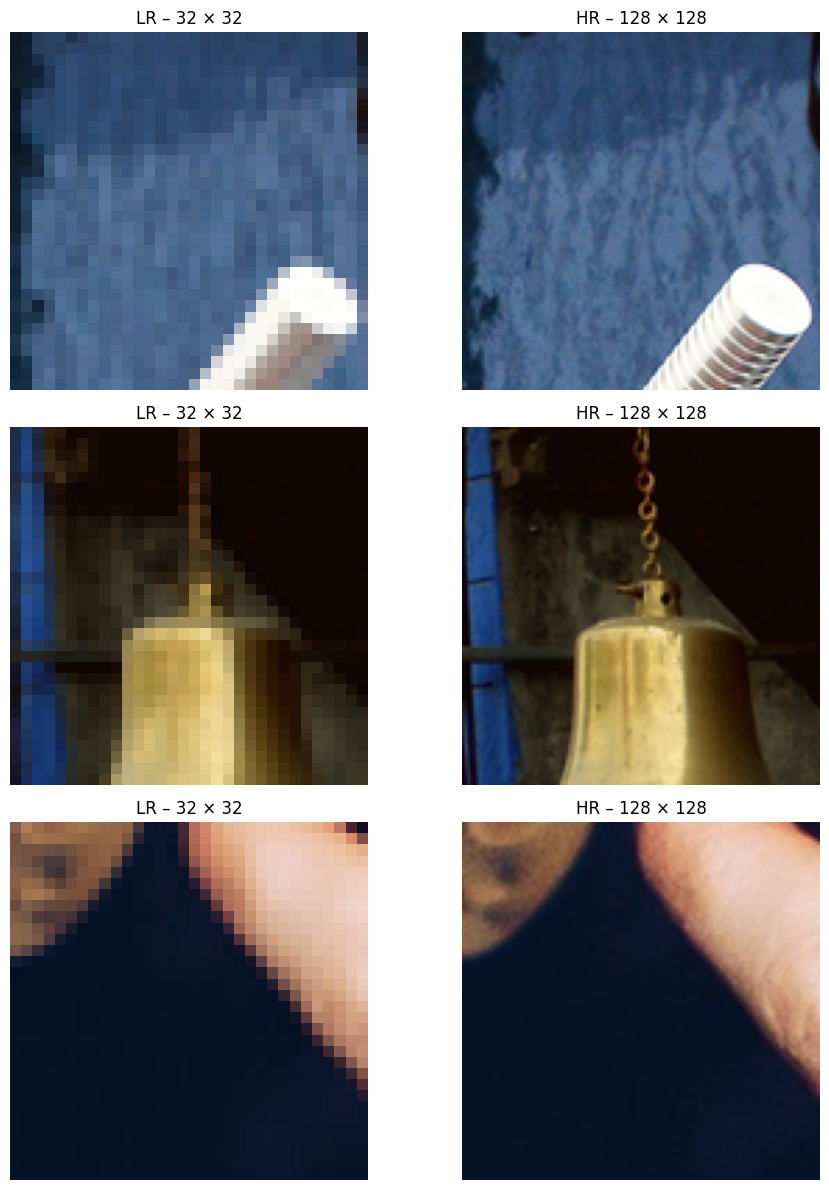

In [57]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

random_indices = random.sample(range(len(X_train)), 3)

for i, idx in enumerate(random_indices):

    axes[i, 0].imshow(X_train[idx])
    axes[i, 0].set_title("LR – 32 × 32")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_train[idx])
    axes[i, 1].set_title("HR – 128 × 128")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

<small>

> Kao što se može videti, **LR** i **HR patch**-evi **odgovaraju jedan drugom**, a **razlika u rezoluciji** je jasno **uočljiva**, što potvrđuje da je **postupak pripreme podataka** uspešno izvršen.
</small>

#### V : Čuvanje pripremljenih trening i validacionih skupova

<small>

Nakon završene pripreme podataka, **trening** i **validacioni skupovi** se čuvaju u $.npy$ formatu, kako bi se pripremljeni **LR** i **HR podaci** mogli kasnije **jednostavno učitati** i koristiti za treniranje i evaluaciju modela, bez ponavljanja postupka pripreme.

</small>

In [ ]:
np.save("./data/X_train.npy", X_train)
np.save("./data/y_train.npy", y_train)
np.save("./data/X_val.npy", X_val)
np.save("./data/y_val.npy", y_val)